## 0. Libraries

In [1]:
# Import LoopDetect core and numpy
import numpy as np
import loopdetect.core as ld
import loopdetect.examples as lde
import numdifftools
import pandas as pd

from scipy.integrate import odeint
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

d:\Work\StudentJob\Jana Wolf\LoopDetect_2025\env\lib\loopdetect_python_3.12\Lib\site-packages\loopdetect\examples.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## 1. Configuration

In [2]:
from matplotlib import rcParams

rcParams.update({
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "mathtext.fontset": "cm",
    "text.usetex": True,  # requires LaTeX installation
    "axes.linewidth": 1.2,
    "axes.labelsize": 18,
    "axes.titlesize": 18,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 14,
    "figure.dpi": 300,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "xtick.major.size": 6,
    "xtick.minor.size": 3,
    "ytick.major.size": 6,
    "ytick.minor.size": 3,
    "xtick.major.width": 1.0,
    "ytick.major.width": 1.0,
})

colors = ['#EE7733', '#0077BB', '#33BBEE', '#EE3377', '#CC3311', '#009988', '#BBBBBB']

In [3]:
# !conda install typing -y

In [3]:
import sys
from pathlib import Path

ROOT = Path.cwd().parents[0]
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.models.func_huang96_biomod import func_huang96_biomod

In [ ]:
def func_huang96_mapk(y, k):
    """
    Huang & Ferrell (1996) MAPK cascade model.

    Parameters
    ----------
    y : ndarray, shape (24,)
        State vector
    k : dict
        Parameters dictionary

    Returns
    -------
    dxdt : ndarray, shape (24,)
        Time derivatives
    """

    # Unpack parameters
    compartment = 4e-12
    a = k[0]
    d = k[1]
    k = k[2]

    # Copy x to avoid in-place modification
    x = np.asarray(y, dtype=float)
    dxdt = np.zeros_like(x)

    # Assignment rule
    # K_PP_norm (index 23)
    denom = (x[10] + x[9] + x[8] + x[17] + x[18] + x[21] + x[22])
    dxdt[23] = 0.0 if denom == 0 else (x[10] + x[21]) / denom

    # Reactions
    r1a = compartment * (a * x[1] * x[3] - d * x[13])
    r1b = compartment * k * x[13]

    r2a = compartment * (a * x[2] * x[4] - d * x[14])
    r2b = compartment * k * x[14]

    r3a = compartment * (a * x[5] * x[4] - d * x[15])
    r3b = compartment * k * x[15]

    r4a = compartment * (a * x[6] * x[12] - d * x[20])
    r4b = compartment * k * x[20]

    r5a = compartment * (a * x[6] * x[4] - d * x[16])
    r5b = compartment * k * x[16]

    r6a = compartment * (a * x[7] * x[12] - d * x[19])
    r6b = compartment * k * x[19]

    r7a = compartment * (a * x[8] * x[7] - d * x[17])
    r7b = compartment * k * x[17]

    r8a = compartment * (a * x[9] * x[11] - d * x[22])
    r8b = compartment * k * x[22]

    r9a = compartment * (a * x[9] * x[7] - d * x[18])
    r9b = compartment * k * x[18]

    r10a = compartment * (a * x[10] * x[11] - d * x[21])
    r10b = compartment * k * x[21]

    # ODEs
    dxdt[1]  = (-r1a + r1b) / compartment
    dxdt[2]  = (-r2a + r2b) / compartment
    dxdt[3]  = (-r1a + r2b) / compartment
    dxdt[4]  = (r1b - r2a - r3a + r3b - r5a + r5b) / compartment
    dxdt[5]  = (-r3a + r4b) / compartment
    dxdt[6]  = (r3b - r4a - r5a + r6b) / compartment
    dxdt[7]  = (r5b - r6a - r7a + r7b - r9a + r9b) / compartment
    dxdt[8]  = (-r7a + r8b) / compartment
    dxdt[9]  = (r7b - r8a - r9a + r10b) / compartment
    dxdt[10] = (r9b - r10a) / compartment
    dxdt[11] = (-r8a + r8b - r10a + r10b) / compartment
    dxdt[12] = (-r4a + r4b - r6a + r6b) / compartment
    dxdt[13] = (r1a - r1b) / compartment
    dxdt[14] = (r2a - r2b) / compartment
    dxdt[15] = (r3a - r3b) / compartment
    dxdt[16] = (r5a - r5b) / compartment
    dxdt[17] = (r7a - r7b) / compartment
    dxdt[18] = (r9a - r9b) / compartment
    dxdt[19] = (r6a - r6b) / compartment
    dxdt[20] = (r4a - r4b) / compartment
    dxdt[21] = (r10a - r10b) / compartment
    dxdt[22] = (r8a - r8b) / compartment

    return np.array(dxdt, dtype=float)


In [6]:
def solve_func_huang96_mapk(y0, t_span, t_eval, arguments, method="BDF"):
    """
    Solve the Huang96 MAPK model.
    """

    sol = solve_ivp(
        fun=lambda t, y: func_huang96_mapk(t, y, arguments),
        t_span=t_span,
        y0=y0,
        t_eval=t_eval,
        method=method,
        rtol=1e-6,
        atol=1e-9
    )

    return sol


## 2. Main reproduction

#### **Example 4: Full MAPK cascade model**

The model for the mitogen-activated phosphorylation kinase (MAPK) cascade proposed in [5] captures the first, second and third level of a phosphorylation cascade which occurs for example in epidermal growth factor (EGF) signaling. The kinase on the first level can be reversibly phosphorylated once, the kinases on levels two
and three can be reversibly phosphorylated twice. The phosphorylated kinase of the first level acts as kinase for the phosphorylations on the second level, the double
phosphorylated kinase of the second level acts as kinase for the phosphorylations on the third level. One phosphatase per layer is modelled to mediate dephosphorylation(s). For phosphorylations and dephosphorylations, complex formation between the kinase or phosphatases and the substrate are explicitly included giving rise to ten additional species (the formed complexes). We used the model proposed by Huang-Ferrell [5] with implementation and parameter sets as given in the Biomodels database by Qiao and colleagues [6]. The model contains 22 species.

Initial conditions:

| Si  | Notation (this work) | Original notation | Initial value | Sj  | Notation (this work) | Original notation                | Initial value |
|-----|----------------------|-------------------|---------------|-----|----------------------|----------------------------------|---------------|
| S1  | E1                   | E1                | 3.0E−5        | S13 | E1_KKK               | [E1, MAPKKK]                     | 0.0           |
| S2  | E2                   | E2                | 3.0E−4        | S14 | E2_P_KKK             | [E2, MAPKKK*]                    | 0.0           |
| S3  | KKK                  | MAPKKK            | 0.003         | S15 | P_KKK_KK             | [MAPKKK*, MAPKK]                 | 0.0           |
| S4  | P_KKK                | MAPKKK*           | 0.0           | S16 | P_KKK_P_KK           | [MAPKKK*, MAPKK*]                | 0.0           |
| S5  | KK                   | MAPKK             | 1.2           | S17 | PP_KK_K              | [MAPKK**, MAPK]                  | 0.0           |
| S6  | P_KK                 | MAPKK*            | 0.0           | S18 | PP_KK_P_K            | [MAPKK**, MAPK*]                 | 0.0           |
| S7  | PP_KK                | MAPKK**           | 0.0           | S19 | KK_Pase_PP_KK        | [KKPase, MAPKK**]                | 0.0           |
| S8  | K                    | MAPK              | 1.2           | S20 | KK_Pase_P_KK         | [KKPase, MAPKK*]                 | 0.0           |
| S9  | P_K                  | MAPK*             | 0.0           | S21 | K_Pase_PP_K          | [KPase, MAPK**]                  | 0.0           |
| S10 | PP_K                 | MAPK**            | 0.0           | S22 | K_Pase_P_K           | [KPase, MAPK*]                   | 0.0           |
| S11 | KPase                | KPase             | 0.12          |     |                      |                                  |               |
| S12 | KK_Pase              | KKPase            | 3.0E−4        |     |                      |                                  |               |


##### **ODEs of the model**

22 equations

$$
\begin{aligned}
\frac{dS_1}{dt} &= -k_1\,S_1\,S_3 + k_2\,S_{13} + k_3\,S_{13}, \\[6pt]

\frac{dS_2}{dt} &= -k_4\,S_2\,S_4 + k_5\,S_{14} + k_6\,S_{14}, \\[6pt]

\frac{dS_3}{dt} &= -k_1\,S_1\,S_3 + k_2\,S_{13} + k_6\,S_{14}, \\[6pt]

\frac{dS_4}{dt} &=
k_3\,S_{13}
- k_4\,S_2\,S_4
+ k_5\,S_{14}
- k_7\,S_5\,S_4
+ k_8\,S_{15}
+ k_9\,S_{15} \\[4pt]
&\quad
- k_{13}\,S_6\,S_4
+ k_{14}\,S_{16}
+ k_{15}\,S_{16}, \\[6pt]

\frac{dS_5}{dt} &= -k_7\,S_5\,S_4 + k_8\,S_{15} + k_{12}\,S_{20}, \\[6pt]

\frac{dS_6}{dt} &=
k_9\,S_{15}
- k_{10}\,S_6\,S_{12}
+ k_{11}\,S_{20}
- k_{13}\,S_6\,S_4
+ k_{14}\,S_{16}
+ k_{18}\,S_{19}, \\[6pt]

\frac{dS_7}{dt} &=
k_{15}\,S_{16}
- k_{16}\,S_7\,S_{12}
+ k_{17}\,S_{19}
- k_{19}\,S_8\,S_7
+ k_{20}\,S_{17}
+ k_{21}\,S_{17} \\[4pt]
&\quad
- k_{25}\,S_9\,S_7
+ k_{26}\,S_{18}
+ k_{27}\,S_{18}, \\[6pt]

\frac{dS_8}{dt} &= -k_{19}\,S_8\,S_7 + k_{20}\,S_{17} + k_{24}\,S_{22}, \\[6pt]

\frac{dS_9}{dt} &=
k_{21}\,S_{17}
- k_{22}\,S_9\,S_{11}
+ k_{23}\,S_{22}
- k_{25}\,S_9\,S_7
+ k_{26}\,S_{18}
+ k_{30}\,S_{21}, \\[6pt]

\frac{dS_{10}}{dt} &= k_{27}\,S_{18} - k_{28}\,S_{10}\,S_{11} + k_{29}\,S_{21}, \\[6pt]

\frac{dS_{11}}{dt} &=
- k_{22}\,S_9\,S_{11}
+ k_{23}\,S_{22}
+ k_{24}\,S_{22}
- k_{28}\,S_{10}\,S_{11}
+ k_{29}\,S_{21}
+ k_{30}\,S_{21}, \\[6pt]

\frac{dS_{12}}{dt} &=
- k_{10}\,S_6\,S_{12}
+ k_{11}\,S_{20}
+ k_{12}\,S_{20}
- k_{16}\,S_7\,S_{12}
+ k_{17}\,S_{19}
+ k_{18}\,S_{19}, \\[6pt]

\frac{dS_{13}}{dt} &= k_1\,S_1\,S_3 - k_2\,S_{13} - k_3\,S_{13}, \\[6pt]

\frac{dS_{14}}{dt} &= k_4\,S_2\,S_4 - k_5\,S_{14} - k_6\,S_{14}, \\[6pt]

\frac{dS_{15}}{dt} &= k_7\,S_5\,S_4 - k_8\,S_{15} - k_9\,S_{15}, \\[6pt]

\frac{dS_{16}}{dt} &= k_{13}\,S_6\,S_4 - k_{14}\,S_{16} - k_{15}\,S_{16}, \\[6pt]

\frac{dS_{17}}{dt} &= k_{19}\,S_8\,S_7 - k_{20}\,S_{17} - k_{21}\,S_{17}, \\[6pt]

\frac{dS_{18}}{dt} &= k_{25}\,S_9\,S_7 - k_{26}\,S_{18} - k_{27}\,S_{18}, \\[6pt]

\frac{dS_{19}}{dt} &= k_{16}\,S_7\,S_{12} - k_{17}\,S_{19} - k_{18}\,S_{19}, \\[6pt]

\frac{dS_{20}}{dt} &= k_{10}\,S_6\,S_{12} - k_{11}\,S_{20} - k_{12}\,S_{20}, \\[6pt]

\frac{dS_{21}}{dt} &= k_{28}\,S_{10}\,S_{11} - k_{29}\,S_{21} - k_{30}\,S_{21}, \\[6pt]

\frac{dS_{22}}{dt} &= k_{22}\,S_9\,S_{11} - k_{23}\,S_{22} - k_{24}\,S_{22}.
\end{aligned}
$$

##### **Parameter**

 Reaction rate parameters

| Reaction        | Parameter | Value  | Reaction        | Parameter | Value | Reaction        | Parameter | Value |
|-----------------|-----------|--------|-----------------|-----------|-------|-----------------|-----------|-------|
| rct_r1a_a1      | k1        | 1000.0 | rct_r1a_d1      | k2        | 150.0 | rct_r1b_k2      | k3        | 150.0 |
| rct_r2a_a2      | k4        | 1000.0 | rct_r2a_d2      | k5        | 150.0 | rct_r2b_k2      | k6        | 150.0 |
| rct_r3a_a3      | k7        | 1000.0 | rct_r3a_d3      | k8        | 150.0 | rct_r3b_k3      | k9        | 150.0 |
| rct_r4a_a4      | k10       | 1000.0 | rct_r4a_d4      | k11       | 150.0 | rct_r4b_k4      | k12       | 150.0 |
| rct_r5a_a5      | k13       | 1000.0 | rct_r5a_d5      | k14       | 150.0 | rct_r5b_k5      | k15       | 150.0 |
| rct_r6a_a6      | k16       | 1000.0 | rct_r6a_d6      | k17       | 150.0 | rct_r6b_k6      | k18       | 150.0 |
| rct_r7a_a7      | k19       | 1000.0 | rct_r7a_d7      | k20       | 150.0 | rct_r7b_k7      | k21       | 150.0 |
| rct_r8a_a8      | k22       | 1000.0 | rct_r8a_d8      | k23       | 150.0 | rct_r8b_k8      | k24       | 150.0 |
| rct_r9a_a9      | k25       | 1000.0 | rct_r9a_d9      | k26       | 150.0 | rct_r9b_k9      | k27       | 150.0 |
| rct_r10a_a10    | k28       | 1000.0 | rct_r10a_d10    | k29       | 150.0 | rct_r10b_k10    | k30       | 150.0 |


In [4]:
def model_MAPK_22(y, k):
    S1, S2, S3, S4, S5, S6, S7, S8, S9, S10, \
    S11, S12, S13, S14, S15, S16, S17, S18, S19, S20, \
    S21, S22 = y

    k1, k2, k3, k4, k5, k6, k7, k8, k9, k10, \
    k11, k12, k13, k14, k15, k16, k17, k18, k19, k20, \
    k21, k22, k23, k24, k25, k26, k27, k28, k29, k30 = k

    dS1  = -k1*S1*S3 + k2*S13 + k3*S13
    dS2  = -k4*S2*S4 + k5*S14 + k6*S14
    dS3  = -k1*S1*S3 + k2*S13 + k6*S14

    dS4  = (k3*S13 - k4*S2*S4 + k5*S14
            - k7*S5*S4 + k8*S15 + k9*S15
            - k13*S6*S4 + k14*S16 + k15*S16)

    dS5  = -k7*S5*S4 + k8*S15 + k12*S20

    dS6  = (k9*S15 - k10*S6*S12 + k11*S20
            - k13*S6*S4 + k14*S16 + k18*S19)

    dS7  = (k15*S16 - k16*S7*S12 + k17*S19
            - k19*S8*S7 + k20*S17 + k21*S17
            - k25*S9*S7 + k26*S18 + k27*S18)

    dS8  = -k19*S8*S7 + k20*S17 + k24*S22

    dS9  = (k21*S17 - k22*S9*S11 + k23*S22
            - k25*S9*S7 + k26*S18 + k30*S21)

    dS10 = k27*S18 - k28*S10*S11 + k29*S21

    dS11 = (-k22*S9*S11 + k23*S22 + k24*S22
            - k28*S10*S11 + k29*S21 + k30*S21)

    dS12 = (-k10*S6*S12 + k11*S20 + k12*S20
            - k16*S7*S12 + k17*S19 + k18*S19)

    dS13 = k1*S1*S3 - k2*S13 - k3*S13
    dS14 = k4*S2*S4 - k5*S14 - k6*S14
    dS15 = k7*S5*S4 - k8*S15 - k9*S15
    dS16 = k13*S6*S4 - k14*S16 - k15*S16
    dS17 = k19*S8*S7 - k20*S17 - k21*S17
    dS18 = k25*S9*S7 - k26*S18 - k27*S18
    dS19 = k16*S7*S12 - k17*S19 - k18*S19
    dS20 = k10*S6*S12 - k11*S20 - k12*S20
    dS21 = k28*S10*S11 - k29*S21 - k30*S21
    dS22 = k22*S9*S11 - k23*S22 - k24*S22

    return np.array([
        dS1, dS2, dS3, dS4, dS5, dS6, dS7, dS8, dS9, dS10,
        dS11, dS12, dS13, dS14, dS15, dS16, dS17, dS18,
        dS19, dS20, dS21, dS22
    ], dtype=float)

def solve_MAPK_22(initial_conditions, time_points, params):
    sol = solve_ivp(lambda t, y: model_MAPK_22(y, params),
                    [time_points[0], time_points[-1]],
                    initial_conditions,
                    t_eval=time_points,
                    method='LSODA')
    return sol

In [5]:
# Parameters from supplementary material
# Reaction rate constants (k1 ... k30)
k_0 = np.array([
    1000.0, 150.0, 150.0,   # k1  k2  k3
    1000.0, 150.0, 150.0,   # k4  k5  k6
    1000.0, 150.0, 150.0,   # k7  k8  k9
    1000.0, 150.0, 150.0,   # k10 k11 k12
    1000.0, 150.0, 150.0,   # k13 k14 k15
    1000.0, 150.0, 150.0,   # k16 k17 k18
    1000.0, 150.0, 150.0,   # k19 k20 k21
    1000.0, 150.0, 150.0,   # k22 k23 k24
    1000.0, 150.0, 150.0,   # k25 k26 k27
    1000.0, 150.0, 150.0    # k28 k29 k30
], dtype=float)

# Initial conditions for S1 ... S22 (from the table)
y0_0 = np.array([
    3.0e-5,   # S1  (E1)
    3.0e-4,   # S2  (E2)
    0.003,    # S3  (KKK / MAPKKK)
    0.0,      # S4  (P_KKK / MAPKKK*)
    1.2,      # S5  (KK / MAPKK)
    0.0,      # S6  (P_KK / MAPKK*)
    0.0,      # S7  (PP_KK / MAPKK**)
    1.2,      # S8  (K / MAPK)
    0.0,      # S9  (P_K / MAPK*)
    0.0,      # S10 (PP_K / MAPK**)
    0.12,     # S11 (KPase)
    3.0e-4,   # S12 (KK_Pase / KKPase)
    0.0,      # S13 (E1_KKK)
    0.0,      # S14 (E2_P_KKK)
    0.0,      # S15 (P_KKK_KK)
    0.0,      # S16 (P_KKK_P_KK)
    0.0,      # S17 (PP_KK_K)
    0.0,      # S18 (PP_KK_P_K)
    0.0,      # S19 (KKPase_PP_KK)
    0.0,      # S20 (KKPase_P_KK)
    0.0,      # S21 (KPase_PP_K)
    0.0       # S22 (KPase_P_K)
], dtype=float)

labels = ["E1", "E2", "MAPKKK", "MAPKKK*", "MAPKK", "MAPKK*", "MAPKK**", "MAPK", "MAPK*", "MAPK**", "KPase", "KK_Pase", "E1_KKK", "E2_P_KKK", "P_KKK_KK", "P_KKK_P_KK", "PP_KK_K", "PP_KK_P_K", "KKPase_PP_KK", "KKPase_P_KK", "KPase_PP_K", "KPase_P_K"]

# Parameters not yet in supplement data
# perturbation_point = 0.2

### 2.1. First parameter set (original)

In [6]:
# Jacocbian calculation
j_matrix = numdifftools.Jacobian(lambda x: model_MAPK_22(x, k),method="central")(y0_0)
signed_jacobian = np.sign(j_matrix)

In [7]:
# print("Jacobian matrix:")
# pd.DataFrame(j_matrix, index=labels, columns=labels)

In [8]:
# print("Signed Jacobian matrix:")
# pd.DataFrame(signed_jacobian, index=labels, columns=labels)

In [6]:
time_points = np.linspace(0, 1100, 1100)
sol = solve_MAPK_22(y0_0, time_points, k_0)

In [7]:
# Find loops at t=1100
res_tab_complex = ld.find_loops_vset(model_MAPK_22,
                                     vset=[sol.y[:, -1]],
                                     k=k_0,
                                     ) # max_num_loops=10
print(res_tab_complex['loop_rep'][0])

                        loop  length  sign
0                  (0, 2, 0)       2     1
1              (0, 2, 12, 0)       3    -1
2                 (0, 12, 0)       2     1
3              (0, 12, 2, 0)       3    -1
4    (0, 12, 3, 1, 13, 2, 0)       6     1
..                       ...     ...   ...
183                 (17, 17)       1    -1
184                 (18, 18)       1    -1
185                 (19, 19)       1    -1
186                 (20, 20)       1    -1
187                 (21, 21)       1    -1

[188 rows x 3 columns]


In [8]:
ld.loop_summary(res_tab_complex['loop_rep'][0])

length,1,2,3,4,5,6,7,8,9
total,22,30,24,17,26,19,16,22,12
neg,22,0,24,0,26,0,16,0,12
pos,0,30,0,17,0,19,0,22,0


### 2.2. Second parameter set (oscillation behavior)

In [9]:
# Copy y0_0 to y0_1 and change only a few initial conditions
# xini=zeros(26,1);
# xini(1)=1e-07;
# xini(2)=1.2115e-04;
# xini(3)=3.7122e-03;
# xini(5)=4.0658;
# xini(12)=9.4579e-05;
# xini(11)=7.5372e-02;
# xini(8)=2;
# The figure starts at t=9000.

y0_1 = y0_0.copy()
y0_1[0] = 1e-07  # Decrease
y0_1[1] = 1.2115e-4  # Decrease
y0_1[2] = 3.7122e-3  # Decrease
y0_1[4] = 4.0658  # Increase
y0_1[7] = 2.0  # Increase
y0_1[10] = 7.5372e-2  # Increase
y0_1[11] = 9.4579e-5  # Decrease

# create new variable by copy y0_1 and add S23-26 = 0 
y0_1_1 = y0_1.copy()
y0_1_1 = np.append(y0_1_1, [0, 0, 0, 0])

k_1 = np.array([
    1092.2, 43.207, 69.525,   # k1  k2  k3
    1557.6, 94.394, 288.74,   # k4  k5  k6
    1917.9, 75.216, 43.432,   # k7  k8  k9
    368.94, 417.10, 715.05,   # k10 k11 k12
    4583.6, 337.42, 169.57,   # k13 k14 k15
    2021.9, 439.05, 348.42,   # k16 k17 k18
    2663.4, 59.598, 41.954,   # k19 k20 k21
    1443.5, 40.101, 63.433,   # k22 k23 k24
    543.66, 222.11, 117.16,   # k25 k26 k27
    439.90, 176.42, 46.705    # k28 k29 k30
], dtype=float)

In [10]:
# Initial simulation to stablize the system
time_points = np.linspace(0, 9000, 9001)
sol = solve_MAPK_22(y0_1, time_points, k_1)
# sol = solve_huang_biomod_p1(time_points, y0_1_1)

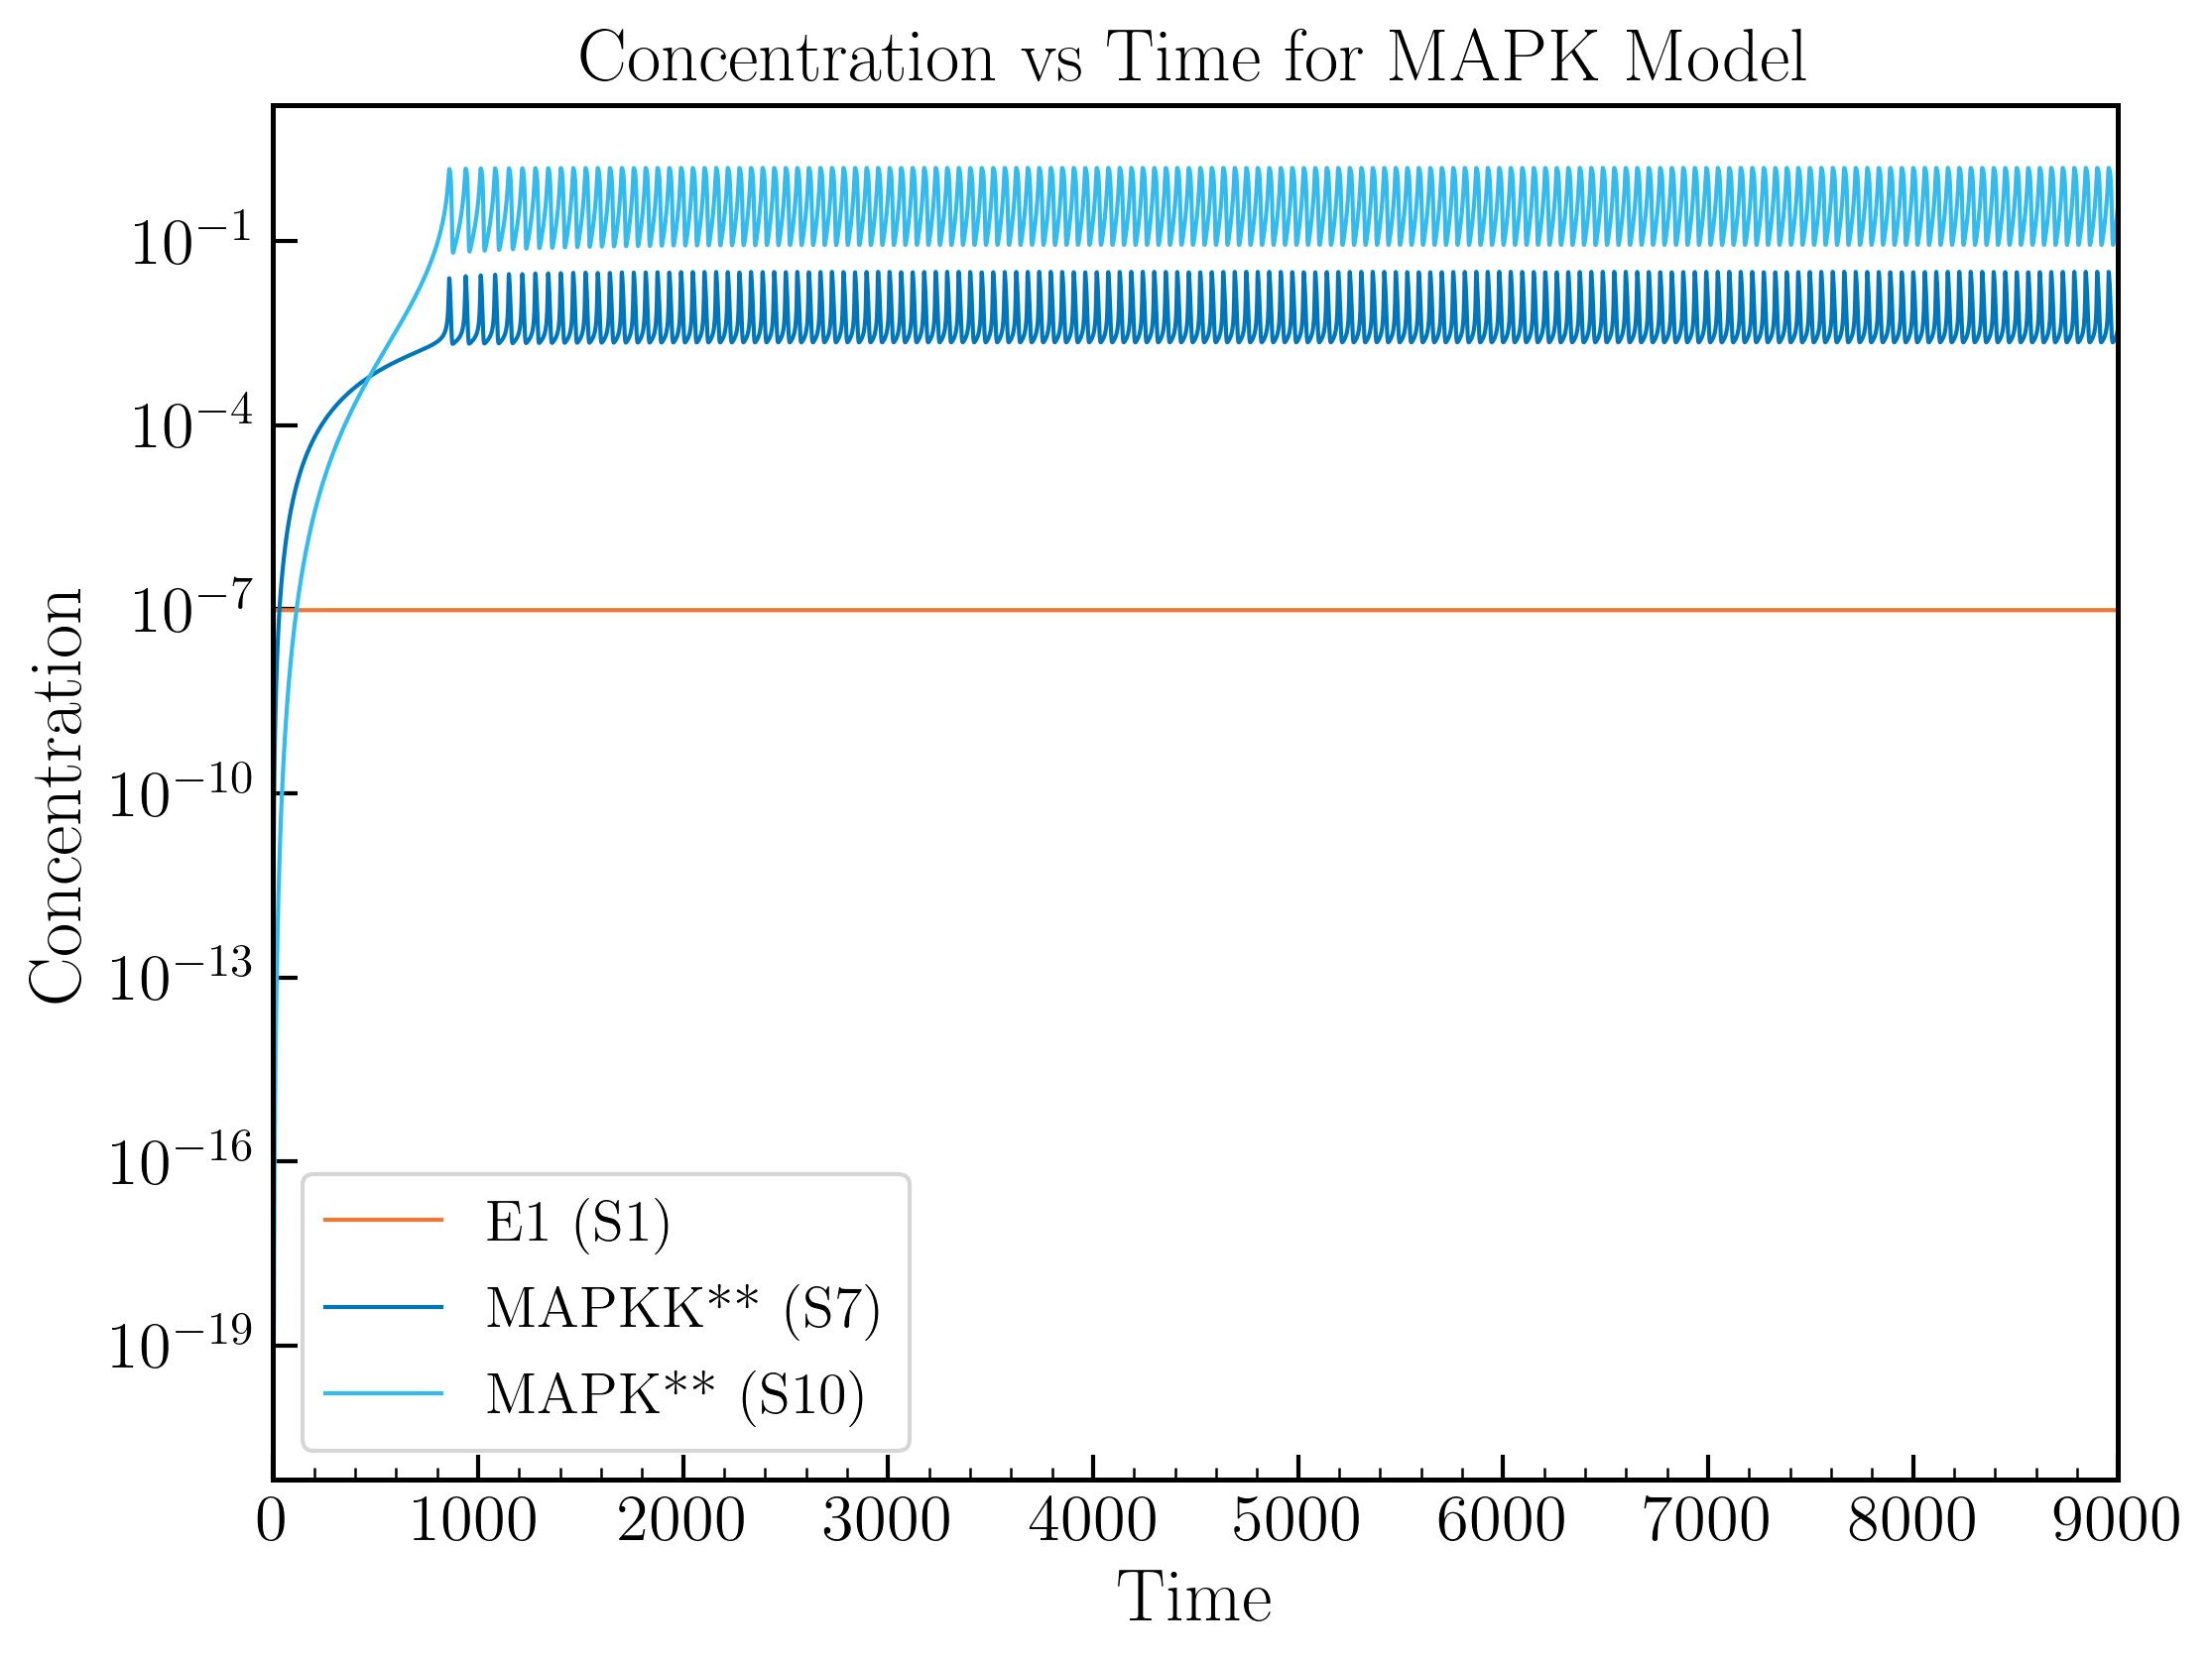

In [12]:
plt.figure(figsize=(8, 6))
investigate_label = ['E1 (S1)', 'MAPKK** (S7)', 'MAPK** (S10)']
investigate_index = [0, 6, 9]
for i, c in enumerate(colors[:3]):
    plt.plot(time_points, sol.y[investigate_index[i]], lw=1, color=c, label=investigate_label[i])
# plt.plot(sol.t, sol.y.T)
# plt.axvline(x=0.2, color='black', linestyle='--', lw=1.5, alpha=0.7)
plt.xlim(0, 9000)
plt.xlabel('Time')
plt.ylabel('Concentration')
plt.yscale('log')
plt.title('Concentration vs Time for MAPK Model')
plt.legend(investigate_label)
plt.show()

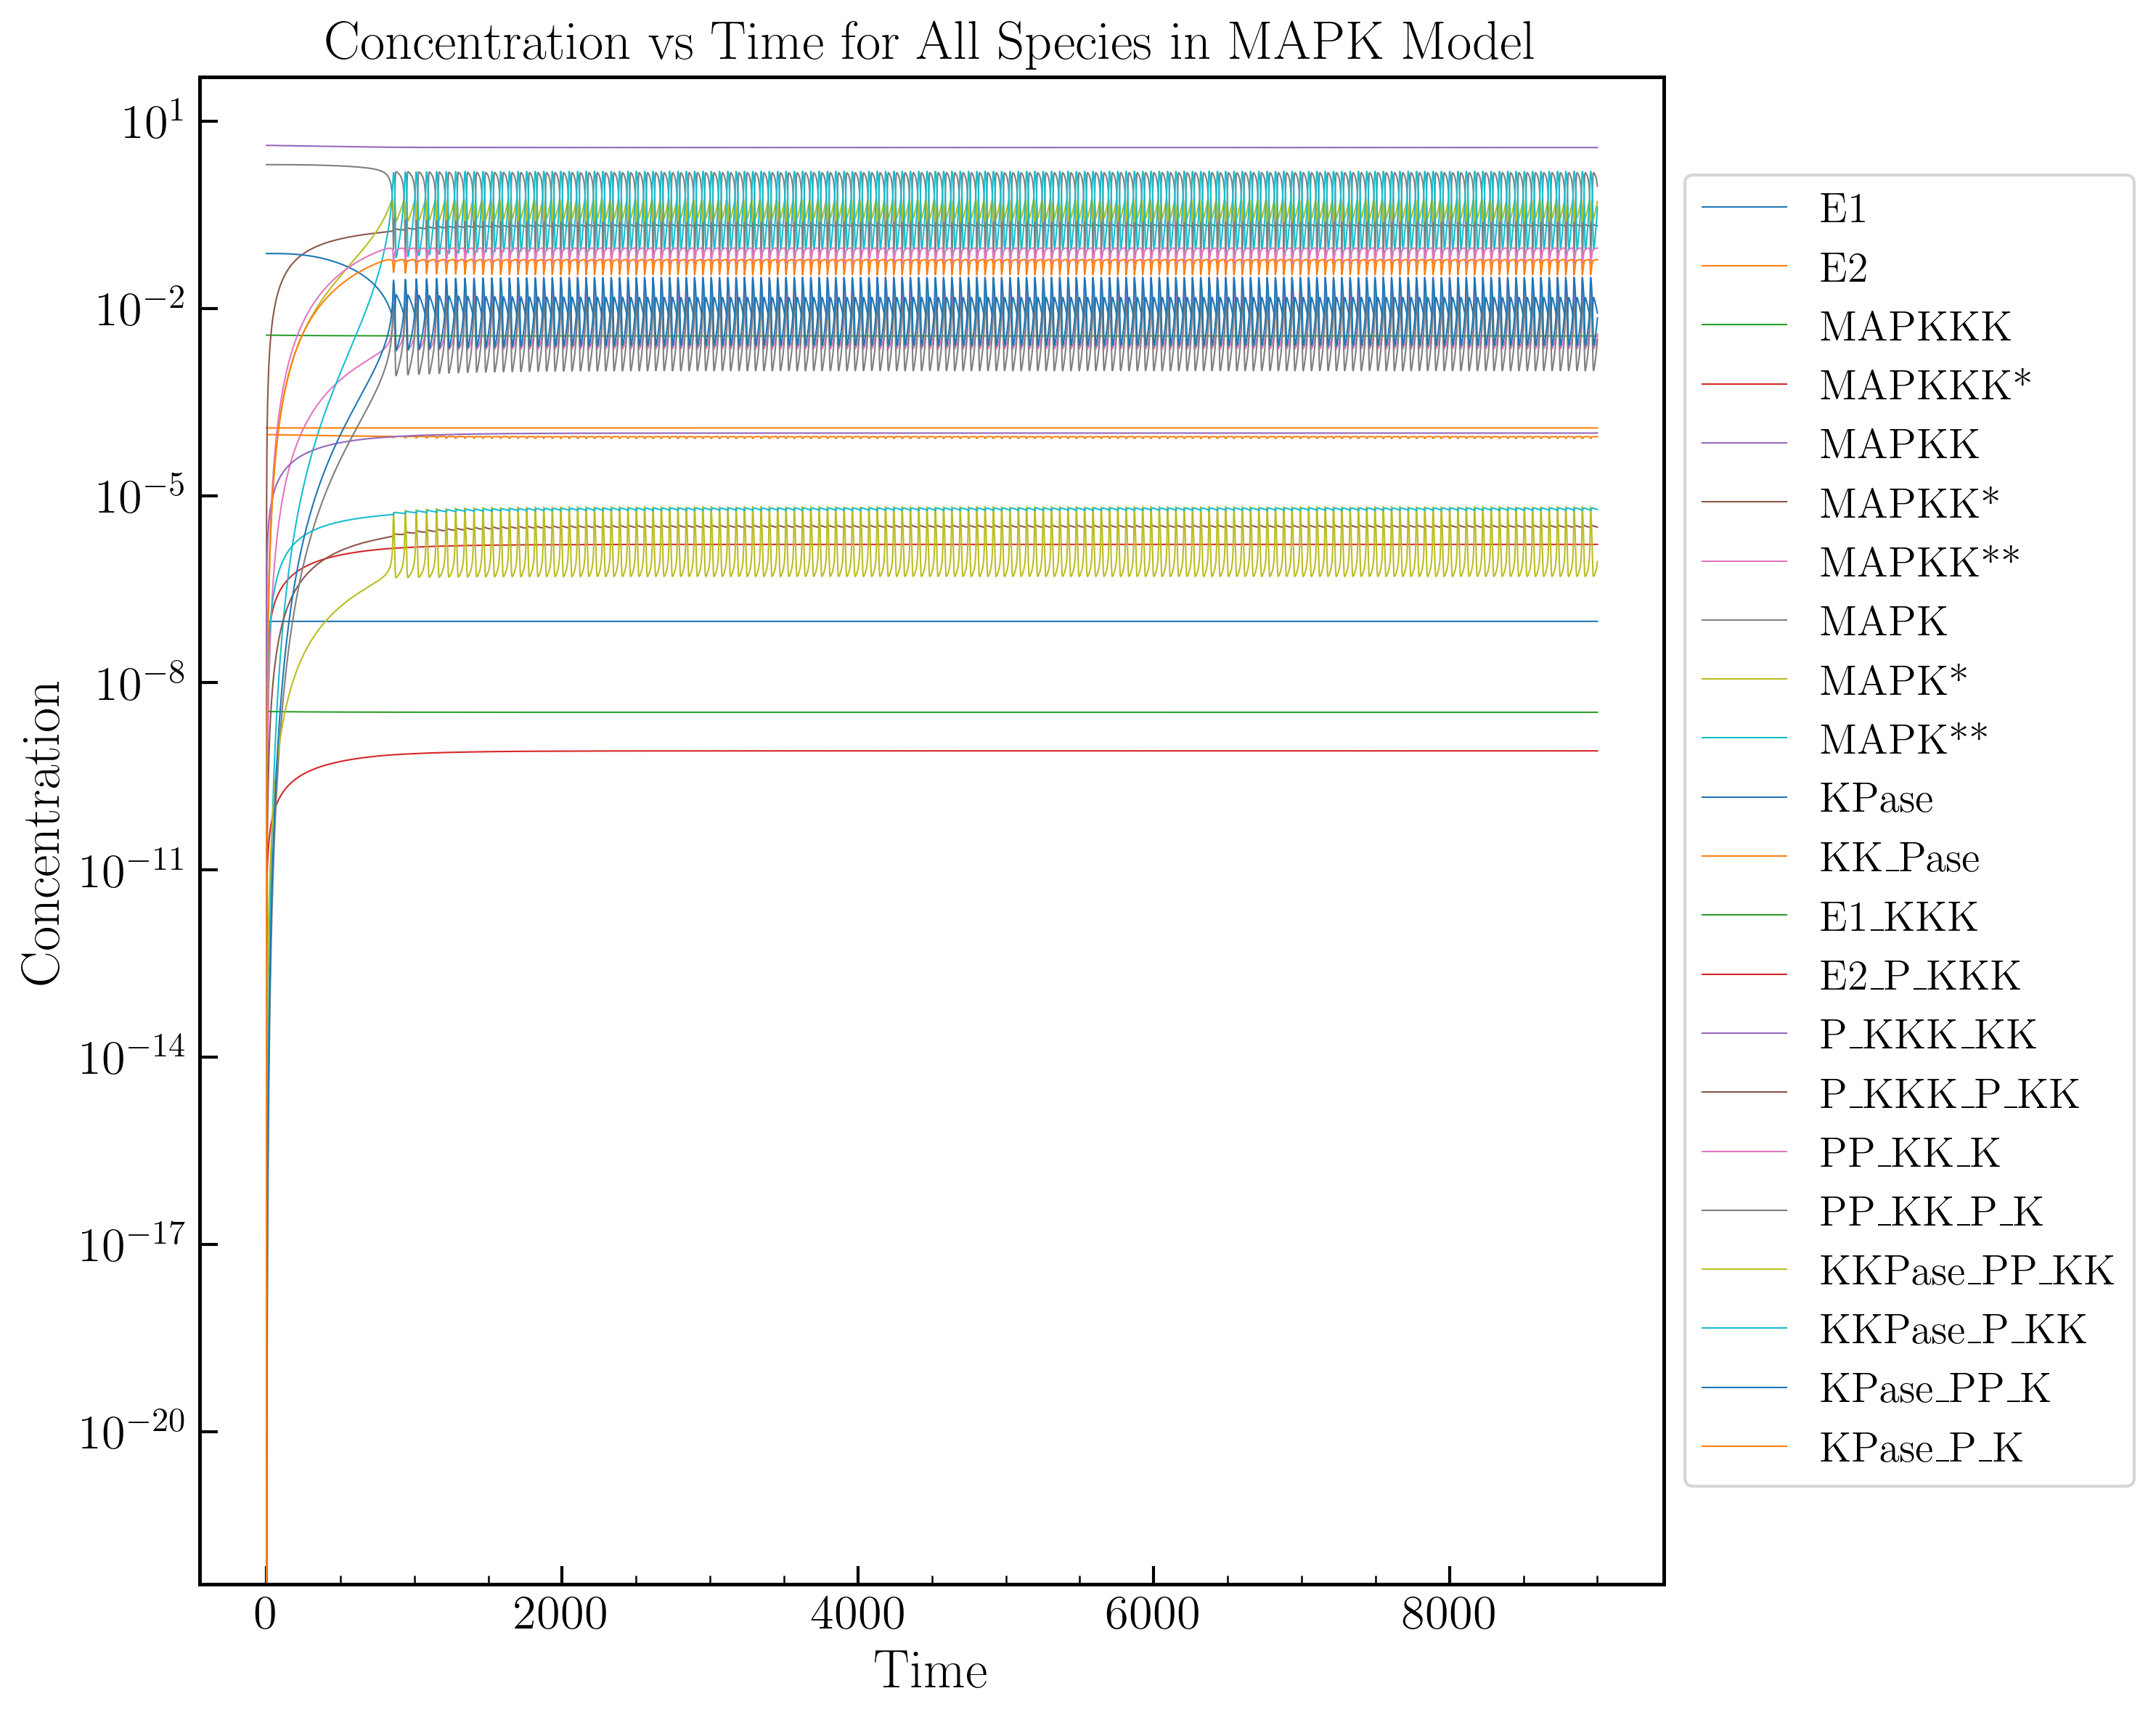

In [15]:
# Plot all species
plt.figure(figsize=(10, 8))
for i in range(22):
    plt.plot(time_points, sol.y[i], lw=0.5, label=labels[i])
plt.xlabel('Time')
plt.ylabel('Concentration')
plt.yscale('log')
plt.title('Concentration vs Time for All Species in MAPK Model')
# put legend outside the plot
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

In [16]:
# From t=9000, simulate another t = [0,300] to create figure
time_points = np.linspace(0, 300, 3001)
sol = solve_MAPK_22(sol.y[:, -1], time_points, k_1)

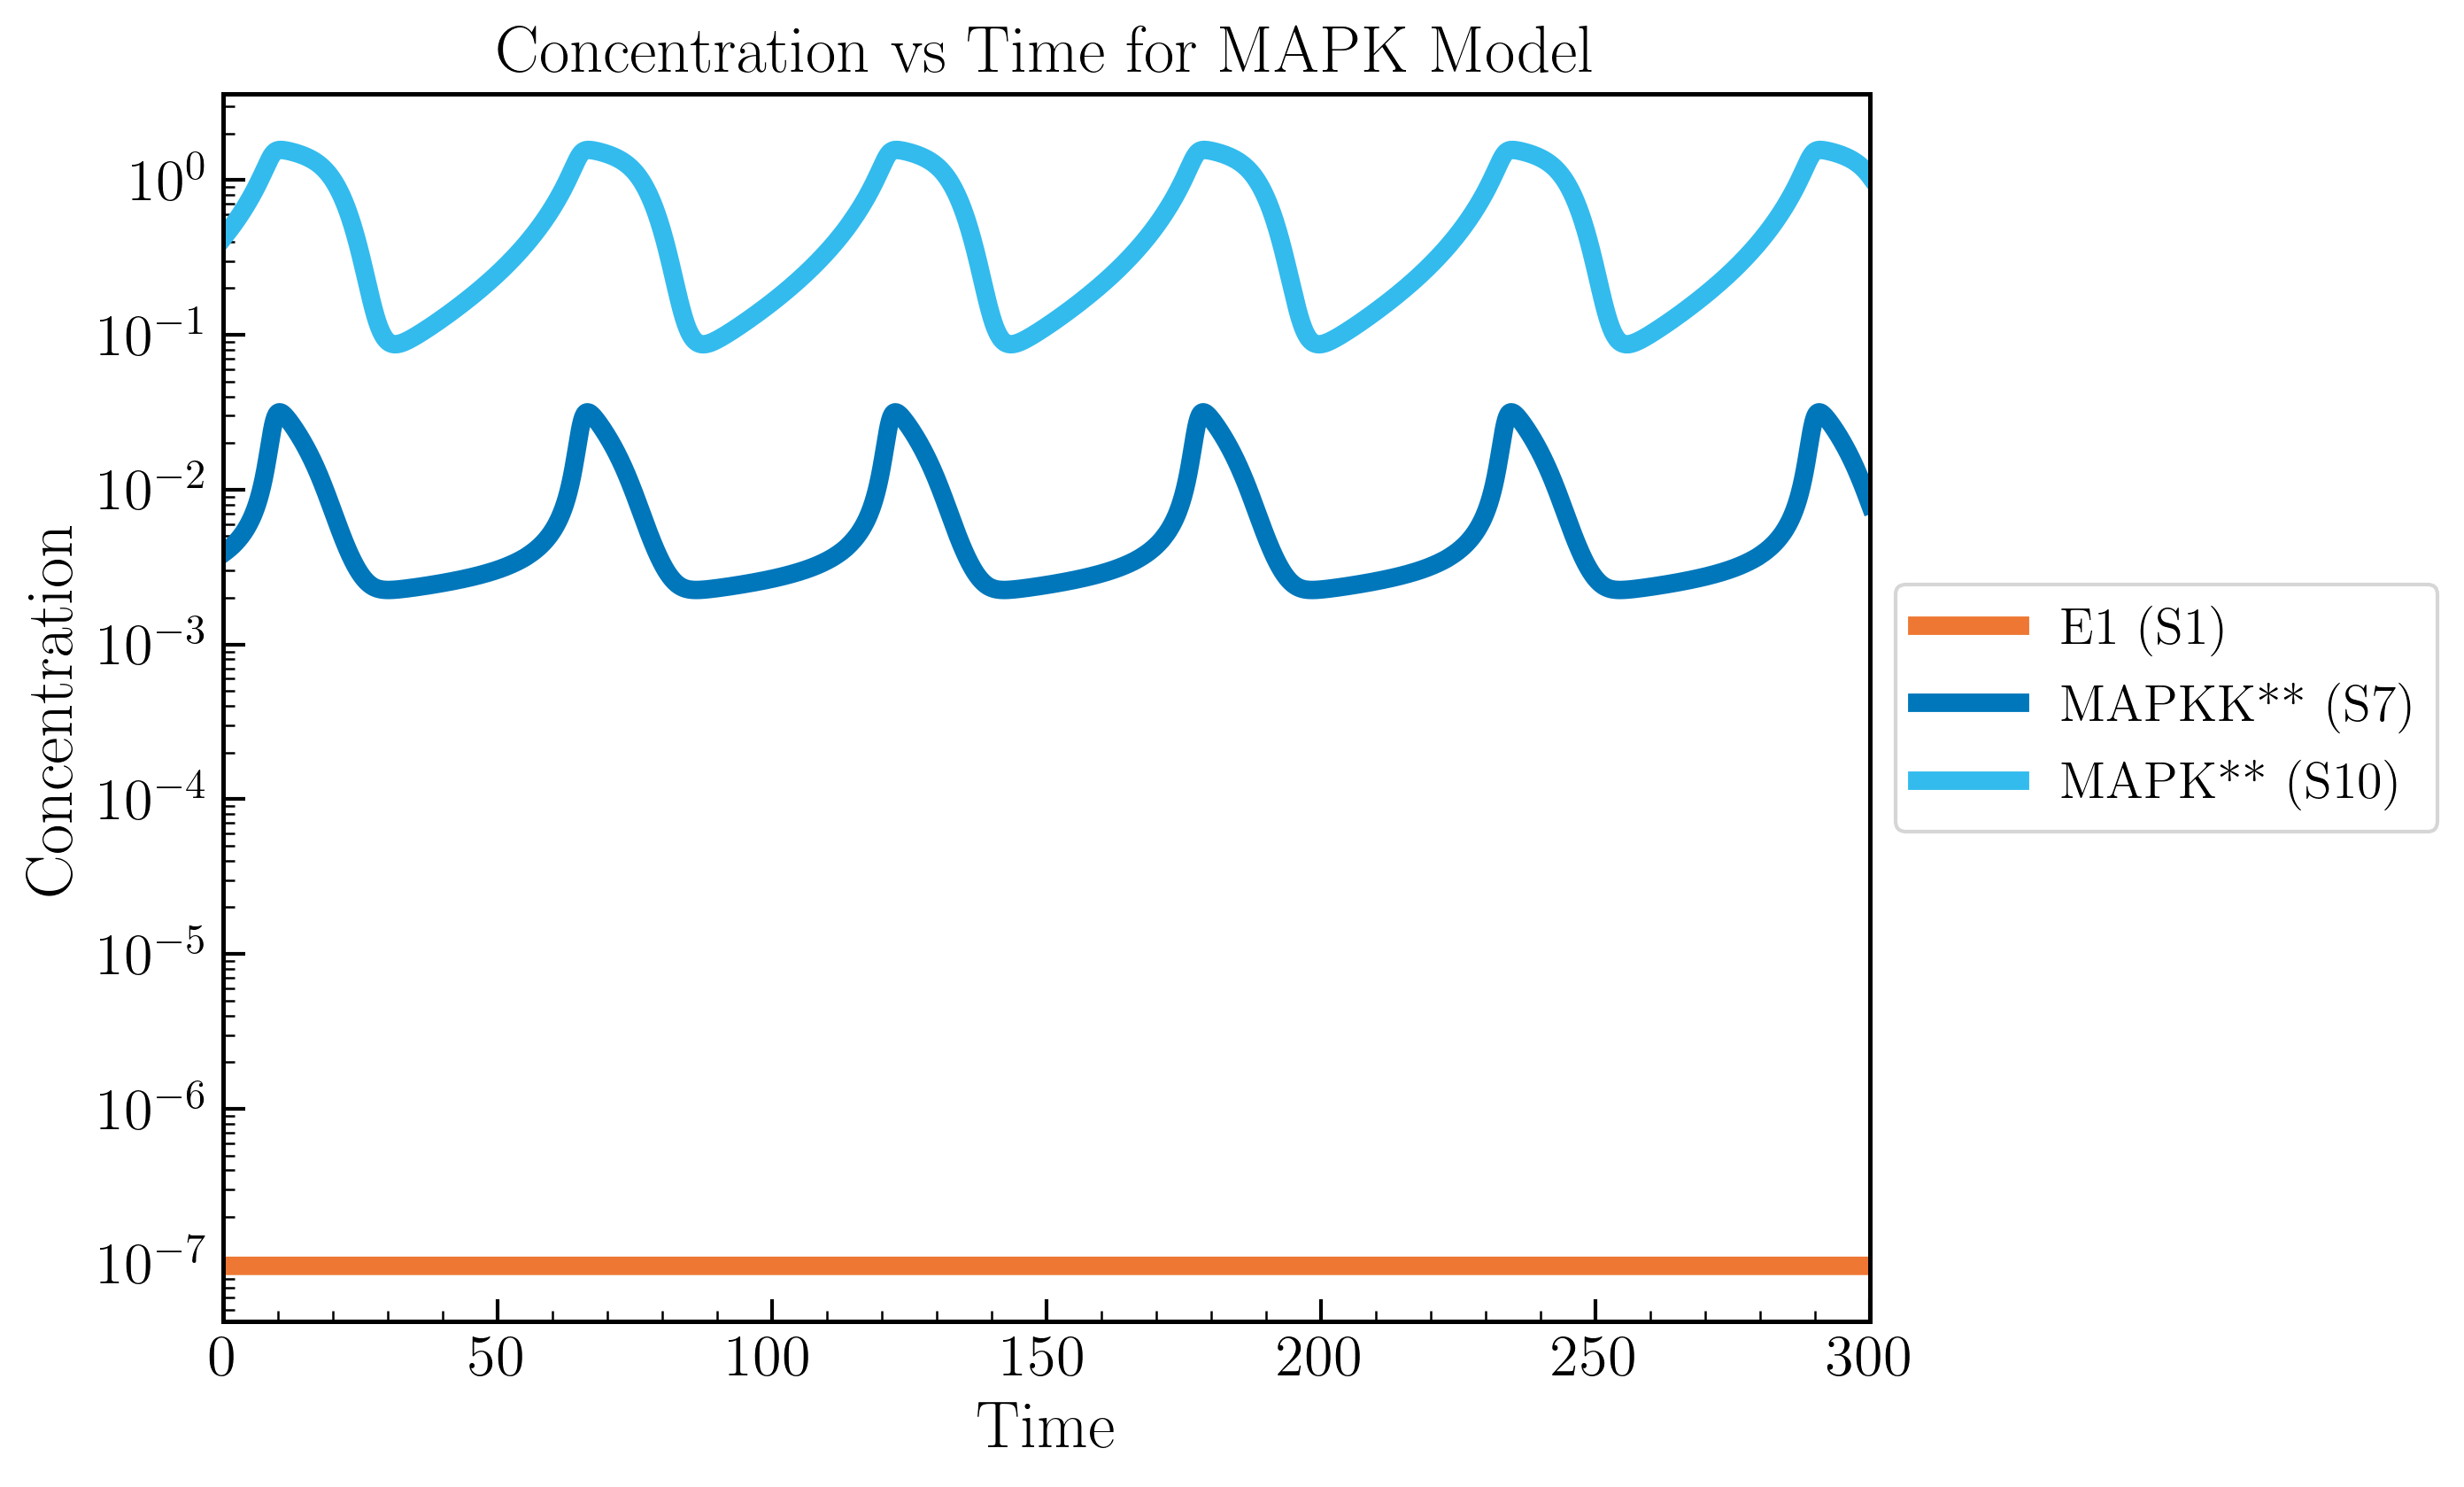

In [21]:
plt.figure(figsize=(8, 6))
investigate_label = ['E1 (S1)', 'MAPKK** (S7)', 'MAPK** (S10)']
investigate_index = [0, 6, 9]
for i, c in enumerate(colors[:3]):
    plt.plot(time_points, sol.y[investigate_index[i]], lw=5, color=c, label=investigate_label[i])
# plt.plot(sol.t, sol.y.T)
# plt.axvline(x=0.2, color='black', linestyle='--', lw=1.5, alpha=0.7)
plt.xlim(0, 300)
plt.xlabel('Time')
plt.ylabel('Concentration')
plt.yscale('log')
plt.title('Concentration vs Time for MAPK Model')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

In [22]:
# Loop detect at sol.y[:, -1] (t=300)
res_tab_complex = ld.find_loops_vset(model_MAPK_22, 
                                     vset=[sol.y[:, -1]], 
                                     k=k_1, 
                                     ) # max_num_loops=10
print(res_tab_complex['loop_rep'][0])
ld.loop_summary(res_tab_complex['loop_rep'][0])

                        loop  length  sign
0                  (0, 2, 0)       2     1
1              (0, 2, 12, 0)       3    -1
2                 (0, 12, 0)       2     1
3              (0, 12, 2, 0)       3    -1
4    (0, 12, 3, 1, 13, 2, 0)       6     1
..                       ...     ...   ...
183                 (17, 17)       1    -1
184                 (18, 18)       1    -1
185                 (19, 19)       1    -1
186                 (20, 20)       1    -1
187                 (21, 21)       1    -1

[188 rows x 3 columns]


length,1,2,3,4,5,6,7,8,9
total,22,30,24,17,26,19,16,22,12
neg,22,0,24,0,26,0,16,0,12
pos,0,30,0,17,0,19,0,22,0


### 2.3. Third Parameter Set (at two defined steady states)

In [23]:
k_2 = np.array([
    337.23, 261.10, 146.07,   # k1  k2  k3
    1841.0, 198.47, 338.44,   # k4  k5  k6
    1226.0, 623.17, 420.00,   # k7  k8  k9
    2960.3, 163.00, 668.20,   # k10 k11 k12
    3383.7, 605.31, 214.65,   # k13 k14 k15
    1956.8, 48.804, 67.970,   # k16 k17 k18
    229.57, 694.13, 43.658,   # k19 k20 k21
    297.00, 301.09, 31.743,   # k22 k23 k24
    3388.7, 485.35, 65.732,   # k25 k26 k27
    974.70, 587.45, 175.91    # k28 k29 k30
], dtype=float)

In [29]:
## Steady state 1
# xini(1)=7.9433e-05
# xini(2)=3.283e-04
# xini(3)=9.2235e-04
# xini(5)=5.1288*49/100;
# xini(6)=5.1288/2;
# xini(7)=5.1288/100;
# xini(12)=2.1238e-04
# xini(11)=5.0345e-01
# xini(8)=8.1552e-01-0.1;
# xini(10)=0.1;

y0_2 = y0_0.copy()
y0_2[0] = 7.9433e-05  # Decrease
y0_2[1] = 3.283e-04   # Decrease
y0_2[2] = 9.2235e-04  # Decrease
y0_2[4] = 5.1288 * 49 / 100  # Decrease
y0_2[5] = 5.1288 / 2  # Decrease
y0_2[6] = 5.1288 / 100  # Decrease
y0_2[7] = 8.1552e-1 - 0.1  # Decrease
y0_2[9] = 0.1  # Increase
y0_2[10] = 5.0345e-1  # Increase
y0_2[11] = 2.1238e-4  # Decrease

## Steady state 2
# xini(1)=7.9433e-05;
# xini(2)=3.283e-04;
# xini(3)=9.2235e-04;
# xini(6)=5.1288/2; %changed around (from x5) --> enforce second steady state
# xini(5)=5.1288/3;
# xini(7)=5.1288/6;
# xini(12)=2.1238e-04;
# xini(11)=5.0345e-01;
# xini(8)=8.1552e-01-0.1;
# xini(10)=0.1;

y0_3 = y0_0.copy()
y0_3[0] = 7.9433e-05  # Decrease
y0_3[1] = 3.283e-04   # Decrease
y0_3[2] = 9.2235e-04  # Decrease
y0_3[4] = 5.1288 / 3  # Decrease
y0_3[5] = 5.1288 / 2  # Decrease
y0_3[6] = 5.1288 / 6  # Decrease
y0_3[7] = 8.1552e-1 - 0.1  # Decrease
y0_3[9] = 0.1  # Increase
y0_3[10] = 5.0345e-1  # Increase
y0_3[11] = 2.1238e-4  # Decrease

In [30]:
# Simulation to stablize the system
time_points = np.linspace(0, 1, 1001)
sol_1 = solve_MAPK_22(y0_2, time_points, k_2)
sol_2 = solve_MAPK_22(y0_3, time_points, k_2)

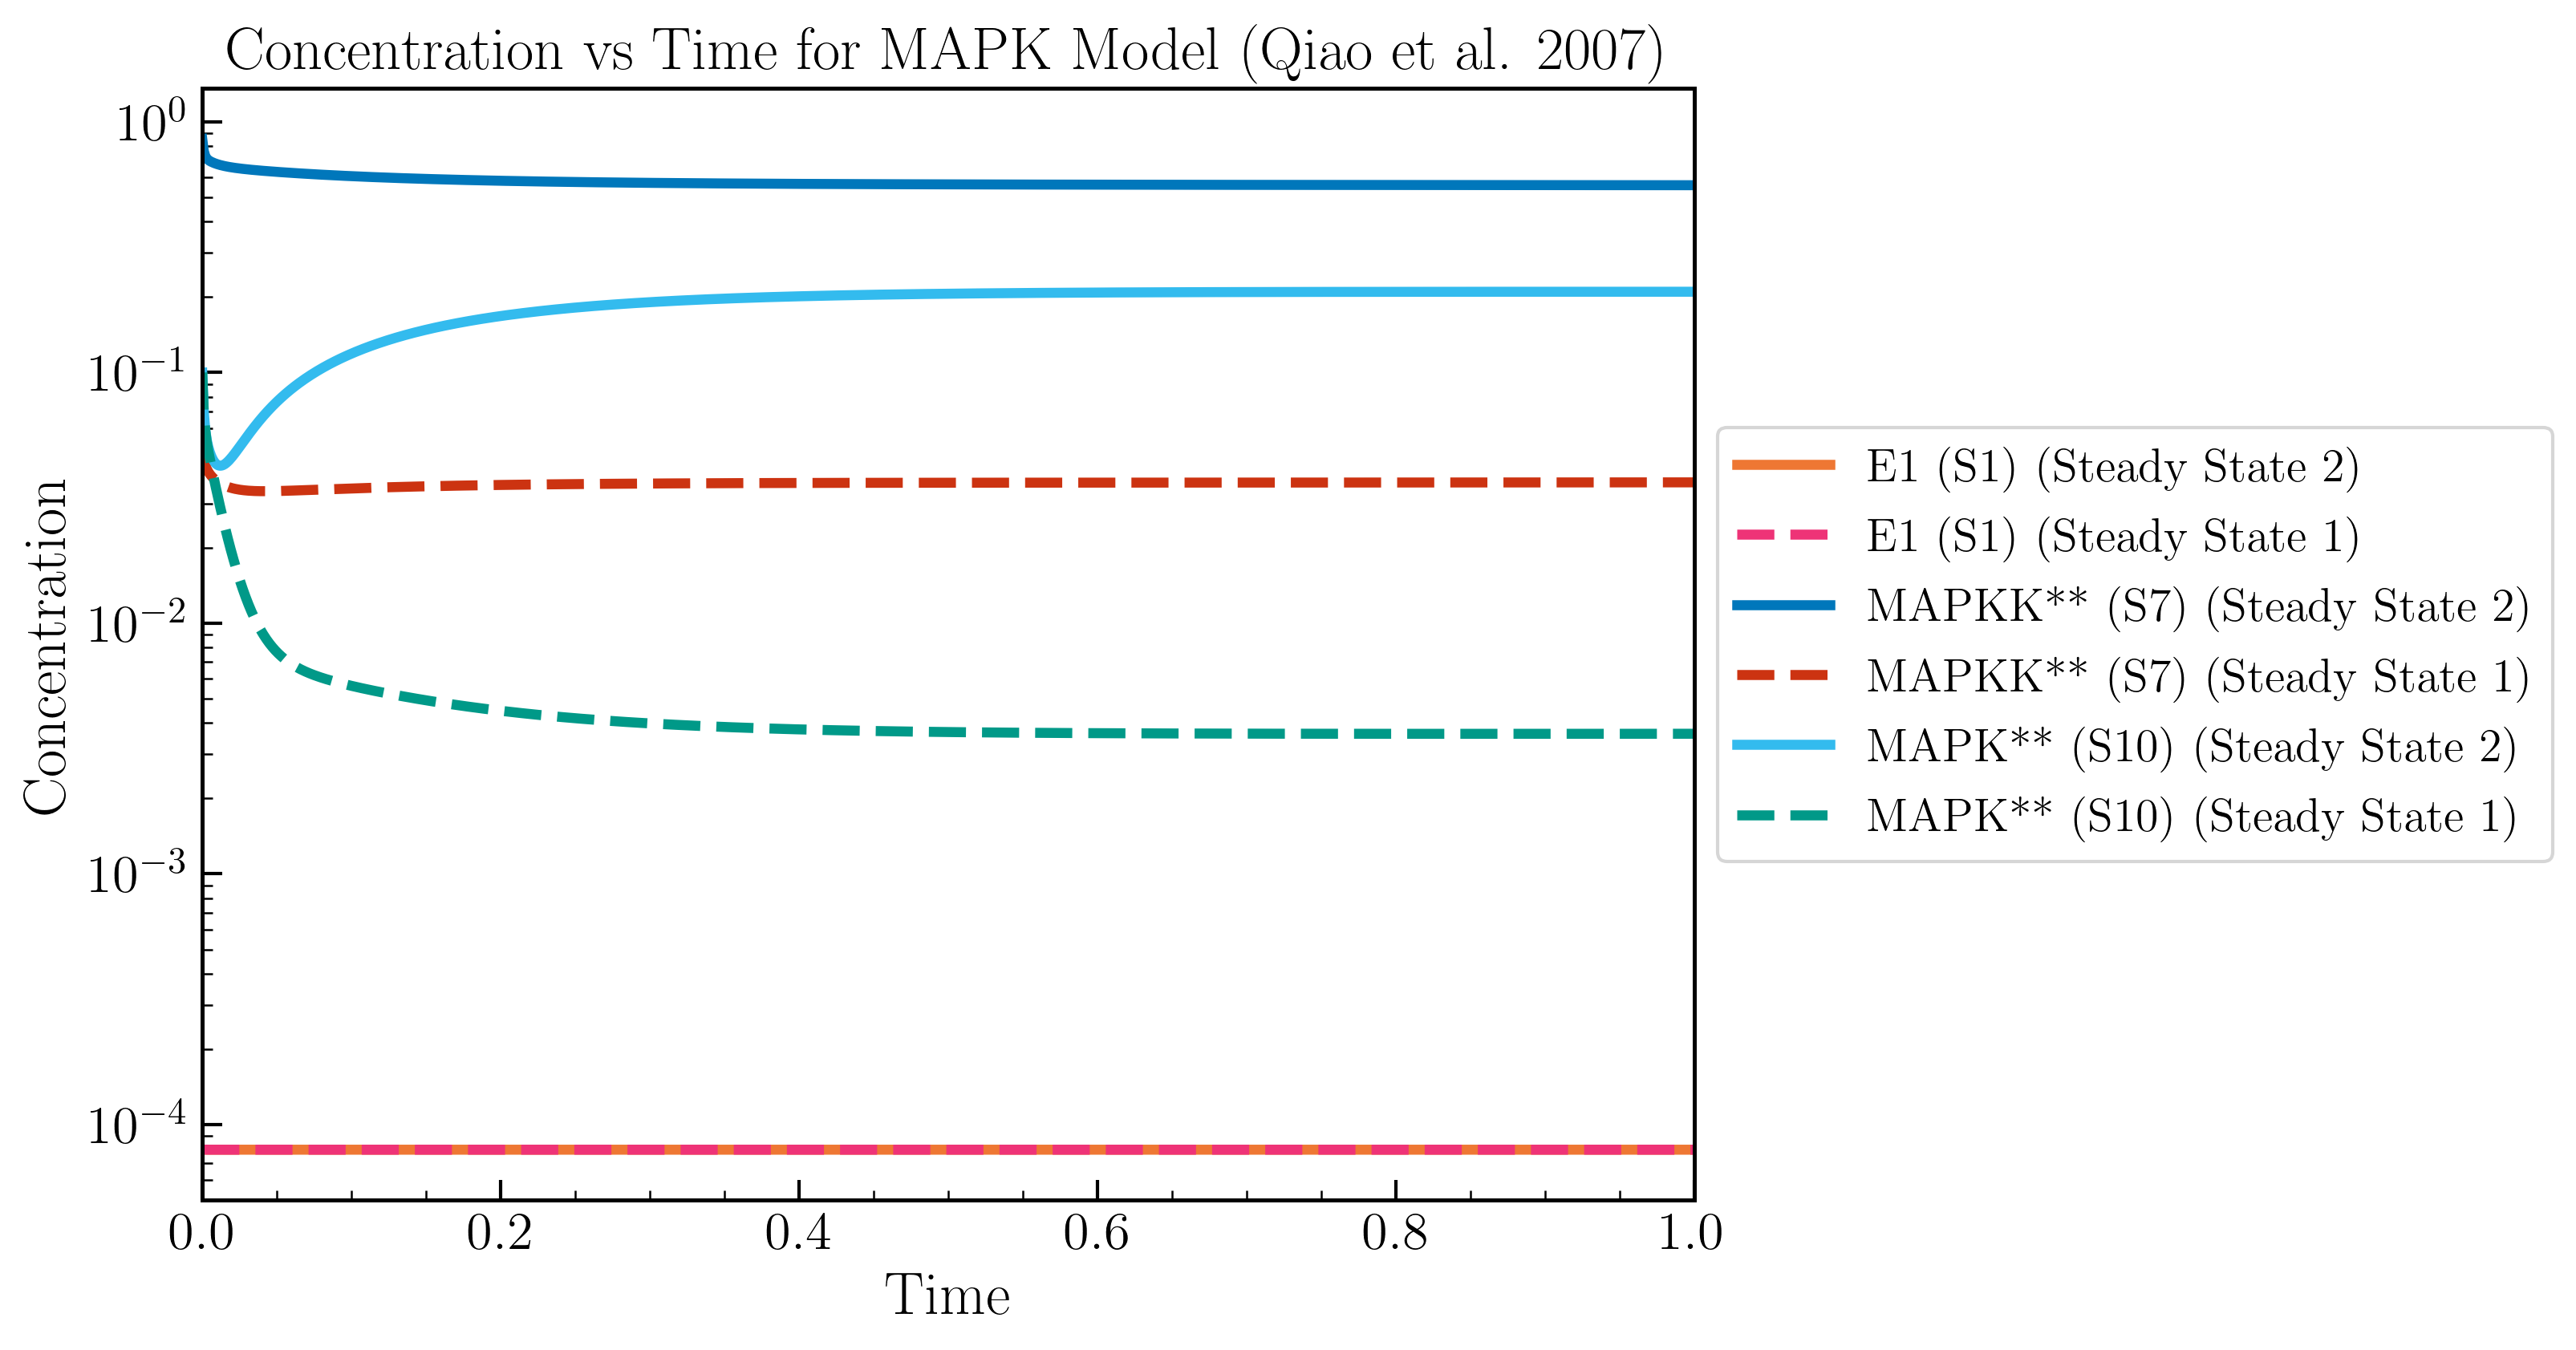

In [37]:
plt.figure(figsize=(8, 6))
investigate_label = ['E1 (S1)', 'MAPKK** (S7)', 'MAPK** (S10)']
investigate_index = [0, 6, 9]
for i, c in enumerate(colors[:3]):
    plt.plot(time_points, sol_2.y[investigate_index[i]], lw=3, color=c, label=f"{investigate_label[i]} (Steady State 2)")
    plt.plot(time_points, sol_1.y[investigate_index[i]], lw=3, color=colors[i+3], linestyle='--', label=f"{investigate_label[i]} (Steady State 1)")
# plt.plot(sol.t, sol.y.T)
# plt.axvline(x=0.2, color='black', linestyle='--', lw=1.5, alpha=0.7)
plt.xlim(0, 1)
plt.xlabel('Time')
plt.ylabel('Concentration')
plt.yscale('log')
plt.title('Concentration vs Time for MAPK Model (Qiao et al. 2007)')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

In [38]:
# Loop detect at sol.y[:, -1] (t=1)
# Steady state 1
res_tab_complex = ld.find_loops_vset(model_MAPK_22, 
                                     vset=[sol_1.y[:, -1]], 
                                     k=k_2, 
                                     ) # max_num_loops=10
print(res_tab_complex['loop_rep'][0])
ld.loop_summary(res_tab_complex['loop_rep'][0])

                        loop  length  sign
0                  (0, 2, 0)       2     1
1              (0, 2, 12, 0)       3    -1
2                 (0, 12, 0)       2     1
3              (0, 12, 2, 0)       3    -1
4    (0, 12, 3, 1, 13, 2, 0)       6     1
..                       ...     ...   ...
183                 (17, 17)       1    -1
184                 (18, 18)       1    -1
185                 (19, 19)       1    -1
186                 (20, 20)       1    -1
187                 (21, 21)       1    -1

[188 rows x 3 columns]


length,1,2,3,4,5,6,7,8,9
total,22,30,24,17,26,19,16,22,12
neg,22,0,24,0,26,0,16,0,12
pos,0,30,0,17,0,19,0,22,0


In [39]:
# Steady state 2
res_tab_complex = ld.find_loops_vset(model_MAPK_22, 
                                     vset=[sol_2.y[:, -1]], 
                                     k=k_2, 
                                     ) # max_num_loops=10
print(res_tab_complex['loop_rep'][0])
ld.loop_summary(res_tab_complex['loop_rep'][0])

                        loop  length  sign
0                  (0, 2, 0)       2     1
1              (0, 2, 12, 0)       3    -1
2                 (0, 12, 0)       2     1
3              (0, 12, 2, 0)       3    -1
4    (0, 12, 3, 1, 13, 2, 0)       6     1
..                       ...     ...   ...
183                 (17, 17)       1    -1
184                 (18, 18)       1    -1
185                 (19, 19)       1    -1
186                 (20, 20)       1    -1
187                 (21, 21)       1    -1

[188 rows x 3 columns]


length,1,2,3,4,5,6,7,8,9
total,22,30,24,17,26,19,16,22,12
neg,22,0,24,0,26,0,16,0,12
pos,0,30,0,17,0,19,0,22,0


In [42]:
#jacobian at steady state 1
j_matrix_1 = numdifftools.Jacobian(lambda x: model_MAPK_22(x, k_2),method="central")(sol_1.y[:, -1])
signed_jacobian_1 = np.sign(j_matrix_1)
print("Jacobian matrix at Steady State 1:")
pd.DataFrame(j_matrix_1, index=labels, columns=labels)

Jacobian matrix at Steady State 1:


,E1,E2,MAPKKK,MAPKKK*,MAPKK,MAPKK*,MAPKK**,MAPK,MAPK*,MAPK**,...,E1_KKK,E2_P_KKK,P_KKK_KK,P_KKK_P_KK,PP_KK_K,PP_KK_P_K,KKPase_PP_KK,KKPase_P_KK,KPase_PP_K,KPase_P_K
E1,-0.308098,0.000000,-0.026767,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,407.17,0.00,0.00,0.00,0.000,0.000,0.000,0.0,0.00,0.000
E2,0.000000,-0.001127,0.000000,-0.604399,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.00,536.91,0.00,0.00,0.000,0.000,0.000,0.0,0.00,0.000
MAPKKK,-0.308098,0.000000,-0.026767,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,261.10,338.44,0.00,0.00,0.000,0.000,0.000,0.0,0.00,0.000
MAPKKK*,0.000000,-0.001127,0.000000,-11499.970355,-0.000751,-0.002072,0.000000,0.000000,0.000000,0.000000,...,146.07,198.47,1043.17,819.96,0.000,0.000,0.000,0.0,0.00,0.000
MAPKK,0.000000,0.000000,0.000000,-3228.099034,-0.000751,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.00,0.00,623.17,0.00,0.000,0.000,0.000,668.2,0.00,0.000
MAPKK*,0.000000,0.000000,0.000000,-8271.266922,0.000000,-0.063012,0.000000,0.000000,0.000000,0.000000,...,0.00,0.00,420.00,605.31,0.000,0.000,67.970,163.0,0.00,0.000
MAPKK**,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-265.187539,-8.374461,-123.616053,0.000000,...,0.00,0.00,0.00,214.65,737.788,551.082,48.804,0.0,0.00,0.000
MAPK,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-173.594856,-8.374461,0.000000,0.000000,...,0.00,0.00,0.00,0.00,694.130,0.000,0.000,0.0,0.00,31.743
MAPK*,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-91.552401,0.000000,-268.964170,0.000000,...,0.00,0.00,0.00,0.00,43.658,485.350,0.000,0.0,175.91,301.090
MAPK**,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-477.006093,...,0.00,0.00,0.00,0.00,0.000,65.732,0.000,0.0,587.45,0.000


In [43]:
print("Signed Jacobian matrix at Steady State 1:")
pd.DataFrame(signed_jacobian_1, index=labels, columns=labels)

Signed Jacobian matrix at Steady State 1:


,E1,E2,MAPKKK,MAPKKK*,MAPKK,MAPKK*,MAPKK**,MAPK,MAPK*,MAPK**,...,E1_KKK,E2_P_KKK,P_KKK_KK,P_KKK_P_KK,PP_KK_K,PP_KK_P_K,KKPase_PP_KK,KKPase_P_KK,KPase_PP_K,KPase_P_K
E1,-1.0,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
E2,0.0,-1.0,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
MAPKKK,-1.0,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
MAPKKK*,0.0,-1.0,0.0,-1.0,-1.0,-1.0,0.0,0.0,0.0,0.0,...,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
MAPKK,0.0,0.0,0.0,-1.0,-1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
MAPKK*,0.0,0.0,0.0,-1.0,0.0,-1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0
MAPKK**,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,-1.0,-1.0,0.0,...,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0
MAPK,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,-1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
MAPK*,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,0.0,-1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0
MAPK**,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


## 3. Additional features

### 3.1. Add subject ID to make the loop result more comprehensible

In [40]:
id_to_subject = {
    0: 'E1 (S1)',
    1: 'E2 (S2)',
    2: 'MAPKKK (S3)',
    3: 'MAPKKK* (S4)',
    4: 'MAPKK (S5)',
    5: 'MAPKK* (S6)',
    6: 'MAPKK** (S7)',
    7: 'MAPK (S8)',
    8: 'MAPK* (S9)',
    9: 'MAPK** (S10)',
    10: 'KPase (S11)',
    11: 'KK_Pase (S12)',
    12: 'E1_KKK (S13)',
    13: 'E2_P_KKK (S14)',
    14: 'P_KKK_KK (S15)',
    15: 'P_KKK_P_KK (S16)',
    16: 'PP_KK_K (S17)',
    17: 'PP_KK_P_K (S18)',
    18: 'KKPase_PP_KK (S19)',
    19: 'KKPase_P_KK (S20)',
    20: 'KPase_PP_K (S21)',
    21: 'KPase_P_K (S22)'
}

df = pd.DataFrame(res_tab_complex['loop_rep'][0]).sort_values(by=['length','loop'])

df["loop_subject"] = df["loop"].apply(
    lambda t: tuple(id_to_subject[i] for i in t)
)

df

,loop,length,sign,loop_subject
166,"(0, 0)",1,-1,"(E1 (S1), E1 (S1))"
167,"(1, 1)",1,-1,"(E2 (S2), E2 (S2))"
168,"(2, 2)",1,-1,"(MAPKKK (S3), MAPKKK (S3))"
169,"(3, 3)",1,-1,"(MAPKKK* (S4), MAPKKK* (S4))"
170,"(4, 4)",1,-1,"(MAPKK (S5), MAPKK (S5))"
...,...,...,...,...
106,"(6, 16, 8, 17, 9, 20, 10, 21, 7, 6)",9,-1,"(MAPKK** (S7), PP_KK_K (S17), MAPK* (S9), PP_K..."
119,"(6, 17, 9, 10, 20, 8, 21, 7, 16, 6)",9,-1,"(MAPKK** (S7), PP_KK_P_K (S18), MAPK** (S10), ..."
126,"(6, 17, 9, 20, 8, 10, 21, 7, 16, 6)",9,-1,"(MAPKK** (S7), PP_KK_P_K (S18), MAPK** (S10), ..."
131,"(6, 17, 9, 20, 10, 8, 21, 7, 16, 6)",9,-1,"(MAPKK** (S7), PP_KK_P_K (S18), MAPK** (S10), ..."


### 3.2. Represent regulation relationship from Jacobian matrix

In [45]:
# Dataframe with columns: 'from', 'to', 'regulation'
# Apply id to subject mapping

print("\nRegulation information for unstimulated conditions:")

regulation_info = pd.DataFrame(signed_jacobian_1, columns=[id_to_subject[i] for i in range(signed_jacobian_1.shape[1])], index=[id_to_subject[i] for i in range(signed_jacobian_1.shape[0])])
regulation_info = regulation_info.stack().reset_index()
regulation_info.columns = ['from', 'to', 'regulation']

# Add regulation information for each variable (-1: inhibition (negative), 1:activation (posotive)). 0 means no regulation and will not be shown in the graph.
regulation_info['regulation_words'] = regulation_info['regulation'].map({-1: 'inhibition (negative)', 1: 'activation (positive)', 0: 'no regulation'})
regulation_info


Regulation information for unstimulated conditions:


,from,to,regulation,regulation_words
0,E1 (S1),E1 (S1),-1.0,inhibition (negative)
1,E1 (S1),E2 (S2),0.0,no regulation
2,E1 (S1),MAPKKK (S3),-1.0,inhibition (negative)
3,E1 (S1),MAPKKK* (S4),0.0,no regulation
4,E1 (S1),MAPKK (S5),0.0,no regulation
...,...,...,...,...
479,KPase_P_K (S22),PP_KK_P_K (S18),0.0,no regulation
480,KPase_P_K (S22),KKPase_PP_KK (S19),0.0,no regulation
481,KPase_P_K (S22),KKPase_P_KK (S20),0.0,no regulation
482,KPase_P_K (S22),KPase_PP_K (S21),0.0,no regulation


### 3.3. Loop Summary in more detail

In [46]:
# Given dataframe from 3.1 named `df`
df

,loop,length,sign,loop_subject
166,"(0, 0)",1,-1,"(E1 (S1), E1 (S1))"
167,"(1, 1)",1,-1,"(E2 (S2), E2 (S2))"
168,"(2, 2)",1,-1,"(MAPKKK (S3), MAPKKK (S3))"
169,"(3, 3)",1,-1,"(MAPKKK* (S4), MAPKKK* (S4))"
170,"(4, 4)",1,-1,"(MAPKK (S5), MAPKK (S5))"
...,...,...,...,...
106,"(6, 16, 8, 17, 9, 20, 10, 21, 7, 6)",9,-1,"(MAPKK** (S7), PP_KK_K (S17), MAPK* (S9), PP_K..."
119,"(6, 17, 9, 10, 20, 8, 21, 7, 16, 6)",9,-1,"(MAPKK** (S7), PP_KK_P_K (S18), MAPK** (S10), ..."
126,"(6, 17, 9, 20, 8, 10, 21, 7, 16, 6)",9,-1,"(MAPKK** (S7), PP_KK_P_K (S18), MAPK** (S10), ..."
131,"(6, 17, 9, 20, 10, 8, 21, 7, 16, 6)",9,-1,"(MAPKK** (S7), PP_KK_P_K (S18), MAPK** (S10), ..."


In [47]:
# Loop summary (A different way)
loop_summary = df.groupby('length').agg(
    num_loops=('loop', 'count'),
    loops=('loop_subject', lambda x: list(x))
).reset_index()
loop_summary

,length,num_loops,loops
0,1,22,"[(E1 (S1), E1 (S1)), (E2 (S2), E2 (S2)), (MAPK..."
1,2,30,"[(E1 (S1), MAPKKK (S3), E1 (S1)), (E1 (S1), E1..."
2,3,24,"[(E1 (S1), MAPKKK (S3), E1_KKK (S13), E1 (S1))..."
3,4,17,"[(MAPKKK (S3), E1_KKK (S13), MAPKKK* (S4), E2_..."
4,5,26,"[(E1 (S1), E1_KKK (S13), MAPKKK* (S4), E2_P_KK..."
5,6,19,"[(E1 (S1), E1_KKK (S13), MAPKKK* (S4), E2 (S2)..."
6,7,16,"[(MAPKKK* (S4), MAPKK* (S6), P_KKK_P_KK (S16),..."
7,8,22,"[(MAPKKK* (S4), MAPKK* (S6), P_KKK_P_KK (S16),..."
8,9,12,"[(MAPKKK* (S4), MAPKK* (S6), P_KKK_P_KK (S16),..."


In [48]:
# make an extended loop summary with added information: 'num_loops_positive', 'num_loops_negative', 'loops_positive', 'loops_negative'
# Loop positive if sign is positive, negative if sign is negative
def count_loop_types(loop_subjects, regulation_info):
    num_positive = 0
    num_negative = 0
    loops_positive = []
    loops_negative = []
    
    for loop in loop_subjects:
        sign = 1
        for i in range(len(loop)):
            from_node = loop[i]
            to_node = loop[(i + 1) % len(loop)]
            regulation = regulation_info[
                (regulation_info['from'] == from_node) & 
                (regulation_info['to'] == to_node)
            ]['regulation'].values[0]
            sign *= regulation
        if sign > 0:
            num_positive += 1
            loops_positive.append(loop)
        else:
            num_negative += 1
            loops_negative.append(loop)
    return num_positive, num_negative, loops_positive, loops_negative
loop_summary_extended = loop_summary.copy()
loop_summary_extended[['num_loops_positive', 'num_loops_negative', 'loops_positive', 'loops_negative']] = loop_summary_extended['loops'].apply(
    lambda x: pd.Series(count_loop_types(x, regulation_info))
)
loop_summary_extended

,length,num_loops,loops,num_loops_positive,num_loops_negative,loops_positive,loops_negative
0,1,22,"[(E1 (S1), E1 (S1)), (E2 (S2), E2 (S2)), (MAPK...",22,0,"[(E1 (S1), E1 (S1)), (E2 (S2), E2 (S2)), (MAPK...",[]
1,2,30,"[(E1 (S1), MAPKKK (S3), E1 (S1)), (E1 (S1), E1...",0,30,[],"[(E1 (S1), MAPKKK (S3), E1 (S1)), (E1 (S1), E1..."
2,3,24,"[(E1 (S1), MAPKKK (S3), E1_KKK (S13), E1 (S1))...",20,4,"[(E1 (S1), MAPKKK (S3), E1_KKK (S13), E1 (S1))...","[(MAPKKK* (S4), P_KKK_KK (S15), MAPKK* (S6), M..."
3,4,17,"[(MAPKKK (S3), E1_KKK (S13), MAPKKK* (S4), E2_...",0,17,[],"[(MAPKKK (S3), E1_KKK (S13), MAPKKK* (S4), E2_..."
4,5,26,"[(E1 (S1), E1_KKK (S13), MAPKKK* (S4), E2_P_KK...",0,26,[],"[(E1 (S1), E1_KKK (S13), MAPKKK* (S4), E2_P_KK..."
5,6,19,"[(E1 (S1), E1_KKK (S13), MAPKKK* (S4), E2 (S2)...",0,19,[],"[(E1 (S1), E1_KKK (S13), MAPKKK* (S4), E2 (S2)..."
6,7,16,"[(MAPKKK* (S4), MAPKK* (S6), P_KKK_P_KK (S16),...",0,16,[],"[(MAPKKK* (S4), MAPKK* (S6), P_KKK_P_KK (S16),..."
7,8,22,"[(MAPKKK* (S4), MAPKK* (S6), P_KKK_P_KK (S16),...",0,22,[],"[(MAPKKK* (S4), MAPKK* (S6), P_KKK_P_KK (S16),..."
8,9,12,"[(MAPKKK* (S4), MAPKK* (S6), P_KKK_P_KK (S16),...",0,12,[],"[(MAPKKK* (S4), MAPKK* (S6), P_KKK_P_KK (S16),..."


In [49]:
# Columns can be rearranged based on preference
cols = ['length', 'num_loops', 'num_loops_positive', 'num_loops_negative', 'loops', 'loops_positive', 'loops_negative']
loop_summary_extended = loop_summary_extended[cols]
loop_summary_extended

,length,num_loops,num_loops_positive,num_loops_negative,loops,loops_positive,loops_negative
0,1,22,22,0,"[(E1 (S1), E1 (S1)), (E2 (S2), E2 (S2)), (MAPK...","[(E1 (S1), E1 (S1)), (E2 (S2), E2 (S2)), (MAPK...",[]
1,2,30,0,30,"[(E1 (S1), MAPKKK (S3), E1 (S1)), (E1 (S1), E1...",[],"[(E1 (S1), MAPKKK (S3), E1 (S1)), (E1 (S1), E1..."
2,3,24,20,4,"[(E1 (S1), MAPKKK (S3), E1_KKK (S13), E1 (S1))...","[(E1 (S1), MAPKKK (S3), E1_KKK (S13), E1 (S1))...","[(MAPKKK* (S4), P_KKK_KK (S15), MAPKK* (S6), M..."
3,4,17,0,17,"[(MAPKKK (S3), E1_KKK (S13), MAPKKK* (S4), E2_...",[],"[(MAPKKK (S3), E1_KKK (S13), MAPKKK* (S4), E2_..."
4,5,26,0,26,"[(E1 (S1), E1_KKK (S13), MAPKKK* (S4), E2_P_KK...",[],"[(E1 (S1), E1_KKK (S13), MAPKKK* (S4), E2_P_KK..."
5,6,19,0,19,"[(E1 (S1), E1_KKK (S13), MAPKKK* (S4), E2 (S2)...",[],"[(E1 (S1), E1_KKK (S13), MAPKKK* (S4), E2 (S2)..."
6,7,16,0,16,"[(MAPKKK* (S4), MAPKK* (S6), P_KKK_P_KK (S16),...",[],"[(MAPKKK* (S4), MAPKK* (S6), P_KKK_P_KK (S16),..."
7,8,22,0,22,"[(MAPKKK* (S4), MAPKK* (S6), P_KKK_P_KK (S16),...",[],"[(MAPKKK* (S4), MAPKK* (S6), P_KKK_P_KK (S16),..."
8,9,12,0,12,"[(MAPKKK* (S4), MAPKK* (S6), P_KKK_P_KK (S16),...",[],"[(MAPKKK* (S4), MAPKK* (S6), P_KKK_P_KK (S16),..."
